
RWANDA FIRM ACTIVITY TRACKER - OSM DATA PIPELINE

This notebook extracts business/firm data from OpenStreetMap for Kigali, Rwanda, cleans it, and saves to Google Drive.
Author: [BeeKayKoozie]
Date: 2026-04






Setup & Drive Mount

In [1]:
# Mount Google Drive and define project paths
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/rwanda-nightlights-firm-activity"
import os
os.makedirs(f"{PROJECT_PATH}/data/raw", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/data/processed", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/outputs/maps", exist_ok=True)
print("Project directories ready.")

Mounted at /content/drive
Project directories ready.


Install Required Libraries

In [2]:
!pip install -q rasterio geopandas earthengine-api geemap osmnx folium scikit-learn matplotlib seaborn

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import folium
from folium.plugins import MarkerCluster

# Authenticate Earth Engine (only once per session)
ee.Authenticate()
ee.Initialize(project='nightlights-project-123456')  # Replace with your GEE project ID
print("Earth Engine initialized.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.5 MB/s eta 0:00:00
Earth Engine initialized.


Download Rwanda Administrative Boundary (Shapefile)
Instead of manual bounding box, we'll use a proper shapefile from GEE or a public source. Here we fetch Rwanda's boundary from FAO GAUL dataset.

In [3]:
# Get Rwanda boundary from FAO GAUL (level 0)
rwanda = ee.FeatureCollection("FAO/GAUL/2015/level0") \
           .filter(ee.Filter.eq('ADM0_NAME', 'Rwanda'))
# Convert to GeoJSON and then to a Shapely geometry
geojson = rwanda.getInfo()
gdf_rwanda = gpd.GeoDataFrame.from_features(geojson['features'])
# Save for later use
gdf_rwanda.to_file(f"{PROJECT_PATH}/data/processed/rwanda_boundary.geojson", driver='GeoJSON')
print("Rwanda boundary saved.")

Rwanda boundary saved.


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


Download Multi‑Year VIIRS Nightlights (2014–2023) and Clip to Rwanda

In [15]:
# Section 4: Download Available VIIRS Nightlights and Clip to Rwanda

# Use the correct VIIRS annual collection
# Note: VIIRS Annual V22 has data from 2012 onwards, but we need to filter by system:time_start
collection = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG")
#ee.ImageCollection("NOAA/VIIRS/DNB/ANNUAL_V22")


# Get available years by extracting from system:time_start
def get_year_from_image(img):
    year = ee.Date(img.get('system:time_start')).get('year')
    return img.set('year', year)

collection_with_year = collection.map(get_year_from_image)
available_years = collection_with_year.aggregate_array('year').distinct().sort().getInfo()
print(f"Available years in VIIRS V22 collection: {available_years}")

# Filter to years we want (2015-2023)
years = [y for y in available_years if 2015 <= y <= 2026] if available_years else [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
print(f"Processing years: {years}")

yearly_stats = []

for year in years:
    print(f"\nProcessing year {year}...")

    # Filter by year using system:time_start
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"

    img = collection.filterDate(start_date, end_date).first()

    if img is None:
        print(f"  No image found for {year}, skipping.")
        continue

    # Select the 'avg_rad' band (VIIRS uses avg_rad, not 'average')
    band_name = img.bandNames().getInfo()[0] if img.bandNames().getInfo() else 'avg_rad'
    img_avg = img.select(band_name)
    img_clipped = img_avg.clip(rwanda)

    # Export to Drive as GeoTIFF
    out_tif = f"{PROJECT_PATH}/data/raw/nightlights_{year}.tif"

    try:
        geemap.ee_export_image(
            img_clipped,
            filename=out_tif,
            scale=500,
            region=rwanda.geometry(),
            file_per_band=False
        )
        print(f"  Saved {out_tif}")
    except Exception as e:
        print(f"  Error exporting {year}: {e}")
        continue

    # Compute mean nightlights value for Rwanda
    try:
        stats = img_clipped.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=rwanda.geometry(),
            scale=500,
            maxPixels=1e9
        )
        mean_val = stats.get(band_name).getInfo()
        yearly_stats.append({'year': year, 'mean_nightlights': mean_val})
        print(f"  Mean nightlights: {mean_val:.4f}")
    except Exception as e:
        print(f"  Error computing stats for {year}: {e}")
        yearly_stats.append({'year': year, 'mean_nightlights': np.nan})

# Save yearly summary
pd.DataFrame(yearly_stats).to_csv(f"{PROJECT_PATH}/data/processed/yearly_nightlights_summary.csv", index=False)
print("\nYearly summary saved.")

Available years in VIIRS V22 collection: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Processing years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

Processing year 2015...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2015.tif
  Saved /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2015.tif
  Mean nightlights: 0.1776

Processing year 2016...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2016.tif
  Saved /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2016.tif
  Mean nightlights: -0.0057

Processing year 2017...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2017.tif
  Saved /content/drive/MyDrive/rwanda-nightlights-f

Load Firm Locations (from Existing OSM Data or Re‑extract)
Since we already saved kigali_firms_clean.csv, we'll load it. If not present, we can re‑extract using OSMnx.

In [16]:
# Load clean firm data
firms_csv = f"{PROJECT_PATH}/data/processed/kigali_firms_clean.csv"
if not os.path.exists(firms_csv):
    # If missing, re-run OSM extraction (as in original notebook)
    import osmnx as ox
    place = "Kigali, Rwanda"
    tags = {"amenity": True, "shop": True, "office": True}
    gdf = ox.features.features_from_place(place, tags)
    for col in ["name", "amenity", "shop", "office"]:
        if col not in gdf.columns:
            gdf[col] = None
    gdf = gdf[["name", "amenity", "shop", "office", "geometry"]].copy()
    gdf = gdf[gdf["geometry"].notnull()]
    gdf = gdf[gdf[["amenity", "shop", "office"]].notnull().any(axis=1)]
    gdf["type"] = gdf["amenity"].fillna(gdf["shop"]).fillna(gdf["office"])
    firm_types = ["bank", "restaurant", "cafe", "bar", "pharmacy", "supermarket", "shop"]
    gdf = gdf[gdf["type"].isin(firm_types)]
    gdf = gdf[["type", "geometry"]]
    # Get centroids
    gdf_proj = gdf.to_crs(epsg=3857)
    centroids = gdf_proj.centroid.to_crs(epsg=4326)
    gdf["lat"] = centroids.y
    gdf["lon"] = centroids.x
    gdf["activity_score"] = 1
    # Save
    gdf.to_csv(firms_csv, index=False)
    firms_df = gdf
else:
    firms_df = pd.read_csv(firms_csv)
    # Convert back to GeoDataFrame
    firms_df['geometry'] = gpd.points_from_xy(firms_df.lon, firms_df.lat)
    firms_gdf = gpd.GeoDataFrame(firms_df, geometry='geometry', crs="EPSG:4326")

print(f"Loaded {len(firms_df)} firms.")

Loaded 736 firms.


Spatial Join – Assign Nightlights Values to Each Firm for Each Year
We will open each year's GeoTIFF, extract the pixel value at each firm's location, and compile a panel dataset.

In [17]:
# Initialize a list to store firm-year observations
firm_year_data = []

for year in years:
    tif_path = f"{PROJECT_PATH}/data/raw/nightlights_{year}.tif"
    if not os.path.exists(tif_path):
        continue
    with rasterio.open(tif_path) as src:
        # Extract values at firm coordinates
        coords = [(lon, lat) for lon, lat in zip(firms_df.lon, firms_df.lat)]
        values = list(src.sample(coords))
        nightlights_vals = [v[0] if v[0] > 0 else 0 for v in values]  # clip negatives

    temp_df = firms_df.copy()
    temp_df['year'] = year
    temp_df['nightlights'] = nightlights_vals
    firm_year_data.append(temp_df)

# Combine into one DataFrame
firm_panel = pd.concat(firm_year_data, ignore_index=True)
firm_panel.to_csv(f"{PROJECT_PATH}/data/processed/firm_nightlights_panel.csv", index=False)
print("Firm‑level panel dataset created.")

Firm‑level panel dataset created.


K‑Means Clustering to Detect Firm Clusters
We'll cluster firms based on their geographic coordinates and, optionally, their nightlights intensity.

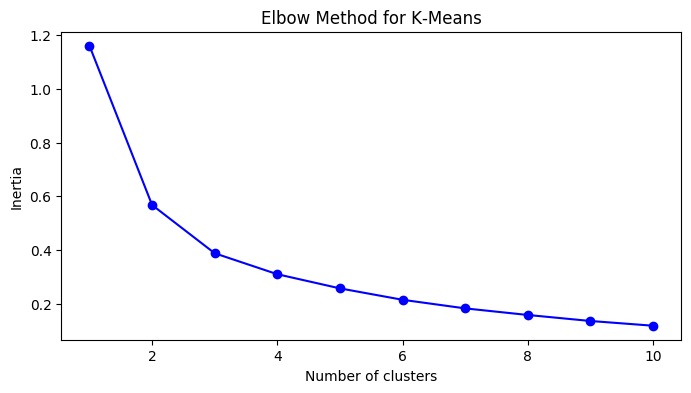

Clustering complete. Cluster labels added.


In [18]:
# Prepare data for clustering: lon, lat, and average nightlights (or latest year)
# For simplicity, use coordinates only first
coords = firms_df[['lon', 'lat']].values

# Determine optimal number of clusters using elbow method (quick)
inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coords)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for K‑Means')
plt.savefig(f"{PROJECT_PATH}/outputs/maps/elbow_plot.png")
plt.show()

# Choose k=3 (or based on elbow) and fit
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
firms_df['cluster'] = kmeans.fit_predict(coords)

# Save clustered firms
firms_df.to_csv(firms_csv.replace('.csv', '_clustered.csv'), index=False)
print("Clustering complete. Cluster labels added.")

Time Series Analysis & Visualization
Plot the average nightlights for each cluster over time and create an interactive map.

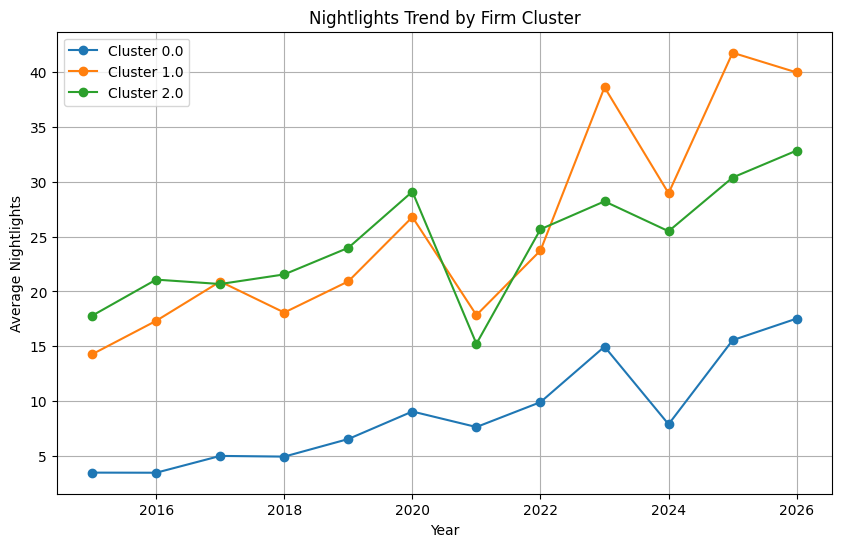

Map saved.


In [19]:
# Merge cluster labels with panel data
panel = pd.read_csv(f"{PROJECT_PATH}/data/processed/firm_nightlights_panel.csv")
clusters = firms_df[['lon', 'lat', 'cluster']].drop_duplicates()
panel = panel.merge(clusters, on=['lon', 'lat'], how='left')

# Aggregate mean nightlights per cluster per year
cluster_trend = panel.groupby(['year', 'cluster'])['nightlights'].mean().reset_index()

# Plot
plt.figure(figsize=(10,6))
for clus in sorted(cluster_trend['cluster'].unique()):
    subset = cluster_trend[cluster_trend['cluster']==clus]
    plt.plot(subset['year'], subset['nightlights'], marker='o', label=f'Cluster {clus}')
plt.xlabel('Year')
plt.ylabel('Average Nightlights')
plt.title('Nightlights Trend by Firm Cluster')
plt.legend()
plt.grid(True)
plt.savefig(f"{PROJECT_PATH}/outputs/maps/cluster_trends.png")
plt.show()

# Create a folium map with firms colored by cluster
m = folium.Map(location=[-1.95, 30.06], zoom_start=12)
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 'beige', 'darkblue', 'darkgreen']
for _, row in firms_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color=colors[row['cluster'] % len(colors)],
        fill=True,
        fill_opacity=0.7,
        popup=f"Type: {row['type']}<br>Cluster: {row['cluster']}"
    ).add_to(m)
m.save(f"{PROJECT_PATH}/outputs/maps/firm_clusters_map.html")
print("Map saved.")

In [20]:
# Section 9: Simulate Survey Data and Merge

# Ensure firms_df exists
if 'firms_df' not in dir():
    firms_csv = f"{PROJECT_PATH}/data/processed/kigali_firms_clean.csv"
    if os.path.exists(firms_csv):
        firms_df = pd.read_csv(firms_csv)
        print(f"Loaded {len(firms_df)} firms from {firms_csv}")
    else:
        print("Firms data not found. Run Section 5 first.")
        firms_df = pd.DataFrame(columns=['type', 'lat', 'lon', 'activity_score'])

if len(firms_df) > 0:
    np.random.seed(42)

    # Create a unique ID column directly
    firms_df_copy = firms_df.copy()
    firms_df_copy['firm_id'] = range(len(firms_df_copy))

    # Simulate survey data using the same firm_id
    survey_df = pd.DataFrame({
        'firm_id': range(len(firms_df_copy)),
        'revenue_estimate': np.random.lognormal(mean=10, sigma=1, size=len(firms_df_copy)),
        'employee_count': np.random.poisson(lam=5, size=len(firms_df_copy)),
        'years_in_operation': np.random.randint(1, 20, size=len(firms_df_copy))
    })

    # Merge directly on firm_id
    merged = firms_df_copy.merge(survey_df, on='firm_id')

    # Save merged dataset
    merged.to_csv(f"{PROJECT_PATH}/data/processed/firms_with_survey_sim.csv", index=False)

    print(f"Simulated survey merge complete.")
    print(f"Firms: {len(firms_df_copy)}, Merged: {len(merged)}")
    print(f"\nSample of merged data:")
    print(merged[['firm_id', 'type', 'revenue_estimate', 'employee_count']].head())
else:
    print("No firms data available to merge.")

Simulated survey merge complete.
Firms: 736, Merged: 736

Sample of merged data:
   firm_id         type  revenue_estimate  employee_count
0        0   restaurant      36196.371320               1
1        1   restaurant      19182.155002               6
2        2   restaurant      42095.180602               4
3        3   restaurant     101015.561318               3
4        4  supermarket      17428.230714               5


In [21]:
# Print key statistics
print("===== PROJECT SUMMARY =====")
print(f"Number of firms: {len(firms_df)}")
print(f"Years covered: {years[0]}-{years[-1]}")
print("\nCluster sizes:")
print(firms_df['cluster'].value_counts().sort_index())
print("\nMean nightlights by cluster (latest year):")
latest_year = panel[panel['year']==years[-1]]
print(latest_year.groupby('cluster')['nightlights'].mean())

===== PROJECT SUMMARY =====
Number of firms: 736
Years covered: 2015-2026

Cluster sizes:
cluster
0     40
1    339
2    357
Name: count, dtype: int64

Mean nightlights by cluster (latest year):
cluster
0.0    17.529730
1.0    39.963465
2.0    32.844985
Name: nightlights, dtype: float64


DiD analysis trial

In [22]:
# Simulate a "treatment" - firms in Cluster 1 received an intervention in 2023
panel['treated'] = (panel['cluster'] == 1).astype(int)
panel['post'] = (panel['year'] == 2023).astype(int)
panel['did'] = panel['treated'] * panel['post']

# Basic DiD regression (can export to Stata)
import statsmodels.formula.api as smf
model = smf.ols('nightlights ~ treated + post + did', data=panel).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            nightlights   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     93.74
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.02e-59
Time:                        21:02:14   Log-Likelihood:                -37068.
No. Observations:                8832   AIC:                         7.414e+04
Df Residuals:                    8828   BIC:                         7.417e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.4317      0.233    100.498      0.0

Create a firm-level productivity proxy
Combine nightlights with simulated revenue

In [24]:
# Load merged survey data
merged = pd.read_csv(f"{PROJECT_PATH}/data/processed/firms_with_survey_sim.csv")

# Create productivity proxy (revenue per employee)
merged['productivity_proxy'] = merged['revenue_estimate'] / merged['employee_count']

# First, add firm_id to panel by matching on lat/lon (unique firm identifier)
# Create a mapping from lat/lon to firm_id using the merged dataset
firm_id_map = merged[['lat', 'lon', 'firm_id']].drop_duplicates()

# Merge firm_id into panel
panel_with_id = panel.merge(firm_id_map, on=['lat', 'lon'], how='left')

# Now merge the revenue and productivity data
panel_with_revenue = panel_with_id.merge(
    merged[['firm_id', 'revenue_estimate', 'productivity_proxy', 'employee_count', 'years_in_operation']],
    on='firm_id',
    how='left'
)

# Correlation between nightlights and productivity
correlation = panel_with_revenue['nightlights'].corr(panel_with_revenue['productivity_proxy'])
print(f"Correlation (nightlights ~ productivity): {correlation:.3f}")

# Additional analysis: nightlights vs revenue
correlation_rev = panel_with_revenue['nightlights'].corr(panel_with_revenue['revenue_estimate'])
print(f"Correlation (nightlights ~ revenue): {correlation_rev:.3f}")

# By cluster
print("\nCorrelation by cluster:")
for clus in panel_with_revenue['cluster'].dropna().unique():
    subset = panel_with_revenue[panel_with_revenue['cluster'] == clus]
    corr = subset['nightlights'].corr(subset['productivity_proxy'])
    print(f"  Cluster {int(clus)}: {corr:.3f}")

# Save the enriched panel
panel_with_revenue.to_csv(f"{PROJECT_PATH}/data/processed/panel_with_revenue.csv", index=False)
print(f"\nEnriched panel saved with {len(panel_with_revenue)} observations")
print(f"Columns: {list(panel_with_revenue.columns)}")

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


Correlation (nightlights ~ productivity): nan
Correlation (nightlights ~ revenue): -0.034

Correlation by cluster:
  Cluster 2: nan
  Cluster 1: nan
  Cluster 0: nan

Enriched panel saved with 9960 observations
Columns: ['type', 'geometry', 'lat', 'lon', 'activity_score', 'year', 'nightlights', 'cluster', 'treated', 'post', 'did', 'firm_id', 'revenue_estimate', 'productivity_proxy', 'employee_count', 'years_in_operation']


# Deep Analysis

In [25]:

# Description: Leverage firm-nightlights panel to answer real measurement questions.

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

In [26]:
# 1. Load Data
# ------------------------------------------------------------------------------
# Panel data (firm-year nightlights)
panel_path = f"{PROJECT_PATH}/data/processed/firm_nightlights_panel.csv"
panel = pd.read_csv(panel_path)

# Firms data with cluster labels
firms_clustered_path = f"{PROJECT_PATH}/data/processed/kigali_firms_clean_clustered.csv"
firms_df = pd.read_csv(firms_clustered_path)

# Convert to GeoDataFrame for spatial operations
firms_gdf = gpd.GeoDataFrame(
    firms_df,
    geometry=gpd.points_from_xy(firms_df.lon, firms_df.lat),
    crs="EPSG:4326"
)

# Add cluster to panel (already done, but ensure it's there)
if 'cluster' not in panel.columns:
    cluster_map = firms_df[['lon', 'lat', 'cluster']].drop_duplicates()
    panel = panel.merge(cluster_map, on=['lon', 'lat'], how='left')

# Ensure cluster is integer
panel['cluster'] = panel['cluster'].astype(int)
firms_df['cluster'] = firms_df['cluster'].astype(int)

print("Data loaded successfully.")
print(f"Panel shape: {panel.shape}")
print(f"Firms shape: {firms_df.shape}")
print(f"Years: {panel['year'].min()} - {panel['year'].max()}")

Data loaded successfully.
Panel shape: (8832, 8)
Firms shape: (736, 6)
Years: 2015 - 2026


panel_latest shape: (736, 8)
Unique types: 6

=== Nightlights Intensity by Firm Type (Latest Year) ===
                  mean        std  count
type                                    
bank         46.763684  15.055392     57
cafe         39.537778  16.450895     63
supermarket  39.179444  16.630554     54
restaurant   38.962557  14.088301    176
bar          33.708947  17.625806     57
pharmacy     31.608632  15.301272    329


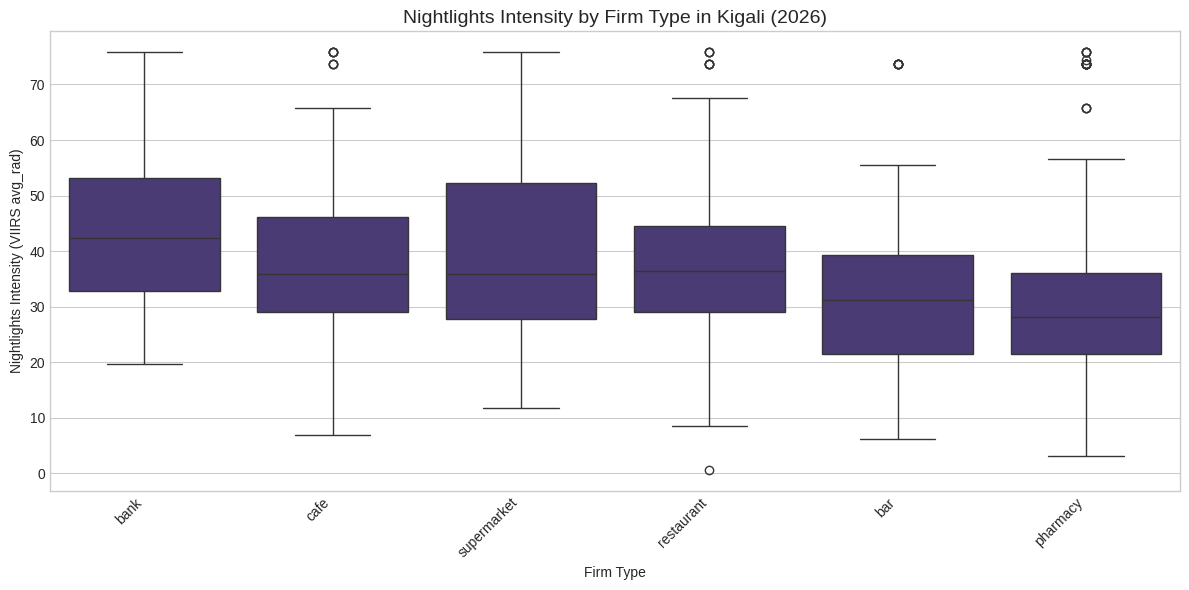

ANOVA: F=13.60, p=1.04e-12

Regression: Nightlights ~ Firm Type + Cluster FE
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 29.4299      3.073      9.578      0.000      23.398      35.462
C(type)[T.bar]           -11.3268      2.739     -4.135      0.000     -16.704      -5.949
C(type)[T.cafe]           -6.7905      2.663     -2.550      0.011     -12.018      -1.563
C(type)[T.pharmacy]      -13.9175      2.097     -6.637      0.000     -18.034      -9.801
C(type)[T.restaurant]     -7.5820      2.219     -3.416      0.001     -11.939      -3.225
C(type)[T.supermarket]    -6.4598      2.771     -2.331      0.020     -11.900      -1.020
C(cluster)[T.1]           20.7795      2.458      8.455      0.000      15.955      25.604
C(cluster)[T.2]           14.2327      2.452      5.804      0.000       9.419      19.047


In [29]:
# ------------------------------------------------------------------------------
# 2. FIRM TYPE SPATIAL SORTING: Which businesses locate in brighter areas?
# ------------------------------------------------------------------------------
# Use latest year for cross-section
latest_year = panel['year'].max()
panel_latest = panel[panel['year'] == latest_year].copy()

# Verify that 'type' is already present (it should be, from firms_df)
if 'type' not in panel_latest.columns:
    # Fallback: reload from firms_df and merge
    firms_clean_path = f"{PROJECT_PATH}/data/processed/kigali_firms_clean.csv"
    if os.path.exists(firms_clean_path):
        firms_df = pd.read_csv(firms_clean_path)
        panel_latest = panel_latest.merge(
            firms_df[['lon', 'lat', 'type']].drop_duplicates(subset=['lon', 'lat']),
            on=['lon', 'lat'],
            how='left'
        )
    else:
        raise FileNotFoundError("Cannot find firms data with 'type' column")

# Drop any rows with missing type (should be none)
panel_latest = panel_latest.dropna(subset=['type'])

# Ensure cluster is present (should already be)
if 'cluster' not in panel_latest.columns:
    cluster_map = firms_df[['lon', 'lat', 'cluster']].drop_duplicates()
    panel_latest = panel_latest.merge(cluster_map, on=['lon', 'lat'], how='left')
panel_latest['cluster'] = panel_latest['cluster'].astype(int)

print(f"panel_latest shape: {panel_latest.shape}")
print(f"Unique types: {panel_latest['type'].nunique()}")

# Compute average nightlights by firm type
type_stats = panel_latest.groupby('type')['nightlights'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
print("\n=== Nightlights Intensity by Firm Type (Latest Year) ===")
print(type_stats)

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=panel_latest, x='type', y='nightlights', order=type_stats.index)
plt.xticks(rotation=45, ha='right')
plt.title(f'Nightlights Intensity by Firm Type in Kigali ({latest_year})', fontsize=14)
plt.xlabel('Firm Type')
plt.ylabel('Nightlights Intensity (VIIRS avg_rad)')
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/outputs/maps/boxplot_type_nightlights.png", dpi=150)
plt.show()

# Statistical test: ANOVA across types
types = panel_latest['type'].unique()
groups = [panel_latest[panel_latest['type'] == t]['nightlights'].dropna() for t in types if len(panel_latest[panel_latest['type'] == t]) > 1]
if len(groups) >= 2:
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"ANOVA: F={f_stat:.2f}, p={p_val:.2e}")

# Regression: nightlights ~ type + cluster (controls for location)
model_type = smf.ols('nightlights ~ C(type) + C(cluster)', data=panel_latest).fit()
print("\nRegression: Nightlights ~ Firm Type + Cluster FE")
print(model_type.summary().tables[1])

Cluster 0: slope=1.192 per year, R²=0.808, p=0.0001
Cluster 1: slope=2.332 per year, R²=0.754, p=0.0002
Cluster 2: slope=1.079 per year, R²=0.521, p=0.0080


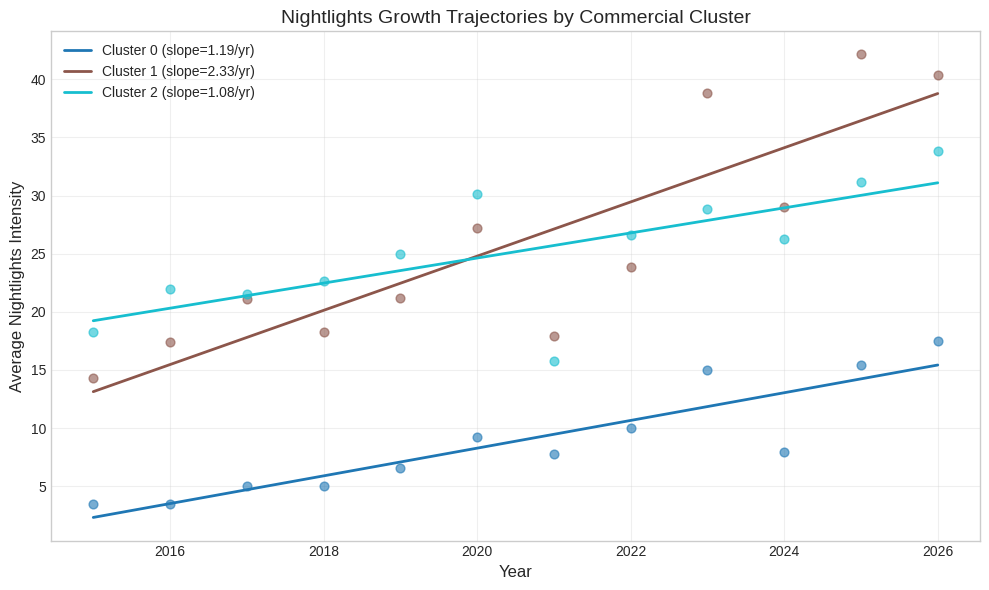


=== Interaction Model: year * cluster ===
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -2400.4280    391.934     -6.125      0.000   -3168.710   -1632.146
C(cluster)[T.1]      -2285.9038    414.413     -5.516      0.000   -3098.249   -1473.559
C(cluster)[T.2]        245.1729    413.309      0.593      0.553    -565.008    1055.354
year                     1.1924      0.194      6.147      0.000       0.812       1.573
year:C(cluster)[T.1]     1.1398      0.205      5.557      0.000       0.738       1.542
year:C(cluster)[T.2]    -0.1133      0.205     -0.554      0.580      -0.514       0.288


In [30]:
# 3. CLUSTER GROWTH DYNAMICS: Are commercial zones diverging?
# ------------------------------------------------------------------------------
# Aggregate mean nightlights per cluster per year
cluster_trend = panel.groupby(['year', 'cluster'])['nightlights'].mean().reset_index()

# Fit linear trends for each cluster
clusters = sorted(panel['cluster'].unique())
trend_results = {}
for clus in clusters:
    subset = cluster_trend[cluster_trend['cluster'] == clus]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['year'], subset['nightlights'])
    trend_results[clus] = {'slope': slope, 'r2': r_value**2, 'p_value': p_value}
    print(f"Cluster {clus}: slope={slope:.3f} per year, R²={r_value**2:.3f}, p={p_value:.4f}")

# Plot with fitted lines
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(clusters)))
for i, clus in enumerate(clusters):
    subset = cluster_trend[cluster_trend['cluster'] == clus]
    plt.scatter(subset['year'], subset['nightlights'], color=colors[i], alpha=0.6, s=40)
    # Fitted line
    slope = trend_results[clus]['slope']
    intercept = np.mean(subset['nightlights']) - slope * np.mean(subset['year'])
    x_range = np.array([subset['year'].min(), subset['year'].max()])
    plt.plot(x_range, intercept + slope * x_range, color=colors[i], linewidth=2,
             label=f'Cluster {clus} (slope={slope:.2f}/yr)')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Nightlights Intensity', fontsize=12)
plt.title('Nightlights Growth Trajectories by Commercial Cluster', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/outputs/maps/cluster_growth_fitted.png", dpi=150)
plt.show()

# Interaction model: test if slopes differ significantly
panel['cluster'] = panel['cluster'].astype(int)
model_interact = smf.ols('nightlights ~ year * C(cluster)', data=panel).fit()
print("\n=== Interaction Model: year * cluster ===")
print(model_interact.summary().tables[1])


Created grid with 1600 points.
Identified 115 candidate informal grid cells.


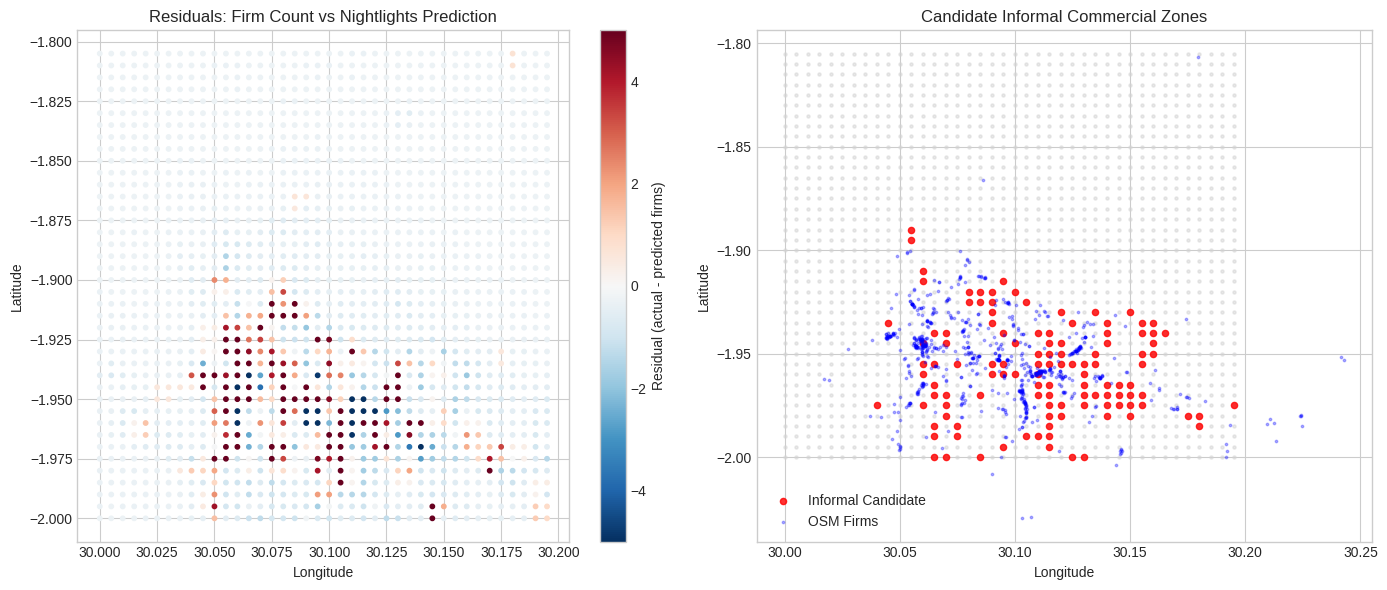

In [31]:
# 4. SPATIAL GRID ANALYSIS: Detecting Informal Market Zones
# ------------------------------------------------------------------------------
# Create a grid of points over Kigali (approx 500m spacing)
# Bounding box of Kigali (approx)
lon_min, lat_min, lon_max, lat_max = 30.0, -2.0, 30.2, -1.8
step = 0.005  # ~500m at equator

lons = np.arange(lon_min, lon_max, step)
lats = np.arange(lat_min, lat_max, step)
grid_points = [Point(lon, lat) for lon in lons for lat in lats]
grid_gdf = gpd.GeoDataFrame(geometry=grid_points, crs="EPSG:4326")
grid_gdf['lon'] = grid_gdf.geometry.x
grid_gdf['lat'] = grid_gdf.geometry.y
print(f"\nCreated grid with {len(grid_gdf)} points.")

# For each grid point, extract nightlights (latest year) and count firms within radius
# Use the latest year's raster
import rasterio
from rasterio.transform import rowcol

tif_latest = f"{PROJECT_PATH}/data/raw/nightlights_{latest_year}.tif"
with rasterio.open(tif_latest) as src:
    # Extract nightlights at grid points
    coords = [(lon, lat) for lon, lat in zip(grid_gdf.lon, grid_gdf.lat)]
    values = list(src.sample(coords))
    grid_gdf['nightlights'] = [v[0] if v[0] > 0 else 0 for v in values]

# Count firms within 500m radius of each grid point (spatial join using buffer)
# Convert grid to projected CRS for accurate distance (EPSG:3857 or 32736 for Rwanda)
grid_proj = grid_gdf.to_crs(epsg=3857)
firms_proj = firms_gdf.to_crs(epsg=3857)

# Create buffer of 500m around each grid point
grid_proj['buffer'] = grid_proj.geometry.buffer(500)

# Spatial join: count firms within each buffer
# Using sjoin is memory-intensive; we'll do a simpler approach: for each grid, count firms within distance
# Since grid is moderate (~1600 points) and firms ~736, we can compute pairwise distances efficiently
from sklearn.neighbors import BallTree

# Convert to radians for haversine
firms_coords = np.deg2rad(firms_gdf[['lat', 'lon']].values)
grid_coords = np.deg2rad(grid_gdf[['lat', 'lon']].values)

# BallTree with haversine metric
tree = BallTree(firms_coords, metric='haversine')
radius_km = 0.5  # 500m
indices = tree.query_radius(grid_coords, r=radius_km / 6371.0)  # radius in radians
grid_gdf['firm_count'] = [len(idx) for idx in indices]

# Model: firm_count ~ nightlights (Poisson)
from sklearn.linear_model import PoissonRegressor

mask = grid_gdf['nightlights'] > 0  # Exclude zero nightlights (no electricity areas)
X = grid_gdf.loc[mask, ['nightlights']]
y = grid_gdf.loc[mask, 'firm_count']

model_pois = PoissonRegressor(alpha=0)
model_pois.fit(X, y)
grid_gdf.loc[mask, 'predicted_firms'] = model_pois.predict(X)
grid_gdf['residual'] = grid_gdf['firm_count'] - grid_gdf['predicted_firms']

# Identify candidate informal zones: high nightlights but low OSM firm count (negative residual)
grid_gdf['informal_candidate'] = (grid_gdf['residual'] < -1) & (grid_gdf['nightlights'] > grid_gdf['nightlights'].median())

print(f"Identified {grid_gdf['informal_candidate'].sum()} candidate informal grid cells.")

# Map residuals
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
# Residuals
sc1 = ax[0].scatter(grid_gdf['lon'], grid_gdf['lat'], c=grid_gdf['residual'],
                    cmap='RdBu_r', s=10, vmin=-5, vmax=5)
ax[0].set_title('Residuals: Firm Count vs Nightlights Prediction', fontsize=12)
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')
plt.colorbar(sc1, ax=ax[0], label='Residual (actual - predicted firms)')

# Highlight informal candidates
ax[1].scatter(grid_gdf['lon'], grid_gdf['lat'], c='lightgray', s=5, alpha=0.5)
candidates = grid_gdf[grid_gdf['informal_candidate']]
ax[1].scatter(candidates['lon'], candidates['lat'], c='red', s=20, alpha=0.8, label='Informal Candidate')
ax[1].scatter(firms_gdf['lon'], firms_gdf['lat'], c='blue', s=3, alpha=0.3, label='OSM Firms')
ax[1].set_title('Candidate Informal Commercial Zones', fontsize=12)
ax[1].set_xlabel('Longitude')
ax[1].set_ylabel('Latitude')
ax[1].legend()
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/outputs/maps/informal_detection_map.png", dpi=150)
plt.show()

# Save grid results
grid_gdf.to_file(f"{PROJECT_PATH}/data/processed/kigali_grid_informal.geojson", driver='GeoJSON')


=== Demonstrating Buffer-Based Nightlights Extraction ===
(This is a demonstration; for full implementation, use rasterstats on all years)
Correlation (point vs 250m buffer): 1.000


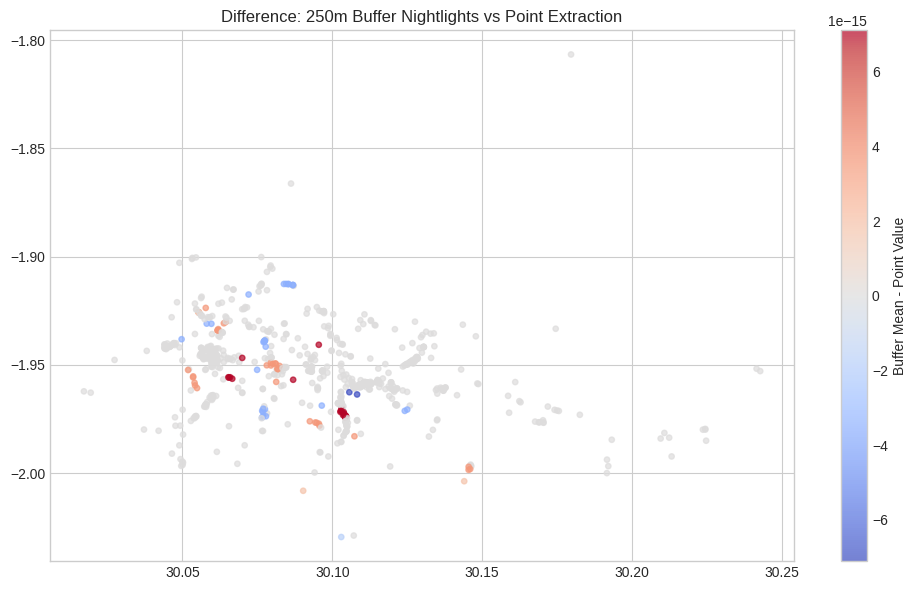

In [32]:
# 5. IMPROVED MEASUREMENT: Nightlights with Buffer (Zonal Statistics)
# ------------------------------------------------------------------------------
# This demonstrates better practice for future work.
print("\n=== Demonstrating Buffer-Based Nightlights Extraction ===")
print("(This is a demonstration; for full implementation, use rasterstats on all years)")

# For one year as example
try:
    from rasterstats import zonal_stats
    # Use firms_gdf with 250m buffer
    stats_250 = zonal_stats(
        firms_gdf, tif_latest, stats="mean", buffer=250,
        geojson_out=True
    )
    firms_gdf['nightlights_250m'] = [s['properties']['mean'] if s['properties']['mean'] is not None else 0 for s in stats_250]

    # Compare point vs buffer
    firms_gdf['nightlights_point'] = panel_latest['nightlights'].values
    corr_buffer = firms_gdf['nightlights_point'].corr(firms_gdf['nightlights_250m'])
    print(f"Correlation (point vs 250m buffer): {corr_buffer:.3f}")

    # Map difference
    fig, ax = plt.subplots(figsize=(10, 6))
    firms_gdf['diff'] = firms_gdf['nightlights_250m'] - firms_gdf['nightlights_point']
    sc = ax.scatter(firms_gdf['lon'], firms_gdf['lat'], c=firms_gdf['diff'],
                    cmap='coolwarm', s=15, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='Buffer Mean - Point Value')
    ax.set_title('Difference: 250m Buffer Nightlights vs Point Extraction', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{PROJECT_PATH}/outputs/maps/buffer_vs_point.png", dpi=150)
    plt.show()
except ImportError:
    print("rasterstats not installed. Install with: pip install rasterstats")
except Exception as e:
    print(f"Buffer extraction demo failed: {e}")



In [33]:
# ------------------------------------------------------------------------------
# 6. EXPORT SUMMARY STATISTICS TABLE
# ------------------------------------------------------------------------------
summary_stats = panel.groupby('cluster')['nightlights'].agg(['mean', 'std', 'min', 'max', 'count']).round(2)
summary_stats.to_csv(f"{PROJECT_PATH}/outputs/cluster_nightlights_summary.csv")

# Create a clean README-style summary
with open(f"{PROJECT_PATH}/outputs/analysis_summary.txt", 'w') as f:
    f.write("===== RWANDA FIRM ACTIVITY TRACKER: ANALYSIS SUMMARY =====\n\n")
    f.write(f"Firms analyzed: {len(firms_df)}\n")
    f.write(f"Years covered: {panel['year'].min()}-{panel['year'].max()}\n\n")
    f.write("--- Firm Type Nightlights (Latest Year) ---\n")
    f.write(type_stats.to_string())
    f.write("\n\n--- Cluster Growth Slopes (Nightlights per Year) ---\n")
    for clus, res in trend_results.items():
        f.write(f"Cluster {clus}: {res['slope']:.3f} (p={res['p_value']:.4f})\n")
    f.write("\n--- Informal Zone Detection ---\n")
    f.write(f"Candidate informal grid cells: {grid_gdf['informal_candidate'].sum()} out of {len(grid_gdf)}\n")
    f.write("\nInterpretation: Cells with high nightlights but few OSM firms may indicate unregistered/informal commercial activity.\n")

print("\n=== ANALYSIS COMPLETE ===")
print("All outputs saved to:", PROJECT_PATH)


=== ANALYSIS COMPLETE ===
All outputs saved to: /content/drive/MyDrive/rwanda-nightlights-firm-activity
